In [1]:
import plotly.graph_objects as go
import numpy as np
import pandas as pd
import csv
import plotly.figure_factory as ff

In [2]:
def qq_func(list1: list[float], list2: list[float]):
    # Создаем 100 точек от 0 до 100 (процентили)
    percentiles = np.linspace(0, 100, 100)
    q1 = np.percentile(list1, percentiles)
    q2 = np.percentile(list2, percentiles)
    
    # --- 3. Построение графика в Plotly ---
    fig = go.Figure()
    
    # Добавляем точки квантилей (Scatter plot)
    fig.add_trace(go.Scatter(
        x=q1, 
        y=q2, 
        mode='markers',
        name='Квантили групп',
        marker=dict(color='royalblue', size=7, opacity=0.8)
    ))
    
    # Добавляем опорную линию (y = x)
    # Если распределения одинаковые, точки лягут ровно на эту красную пунктирную линию
    min_val = min(min(q1), min(q2))
    max_val = max(max(q1), max(q2))
    
    fig.add_trace(go.Scatter(
        x=[min_val, max_val], 
        y=[min_val, max_val], 
        mode='lines',
        name='Опорная линия (y=x)',
        line=dict(color='red', dash='dash', width=2)
    ))
    
    # Настраиваем внешний вид (Layout)
    fig.update_layout(
        title='Two-Sample Q-Q Plot: Сравнение двух списков данных',
        xaxis_title='Квантили Базовый контекст',
        yaxis_title='Квантили Модификация',
        width=700,
        height=700,
        template='plotly_white',  # Светлая тема
        legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01)
    )
    return fig

In [3]:
def read_df(path: str):
    df = pd.read_csv(path, quoting=csv.QUOTE_NONNUMERIC, index_col=0)
    df.index = df.index.astype(int)
    return df

- in_perturb_0 - first - perturb5
- in_perturb_1 - mean - perturb5
- in_perturb_2 - first - perturb10
- in_perturb_3 - mean - perturb10

In [5]:
in_checks = "../data/samples_50/modify_prompt_order/checks.csv"
in_perturb_1 = "../data/samples_50/modify_prompt_order/metrics2/perturb1/generate/ptb_results.csv"

base = read_df(in_checks)
perturb_1 = read_df(in_perturb_1)

In [6]:
# --- 1. Подготовка данных ---
# Замените эти списки на ваши реальные данные
# Для примера сгенерируем две группы (разного размера, но похожие по природе)
list1 = base["similarity"].tolist()
list2_1 = perturb_1["similarity"].tolist()

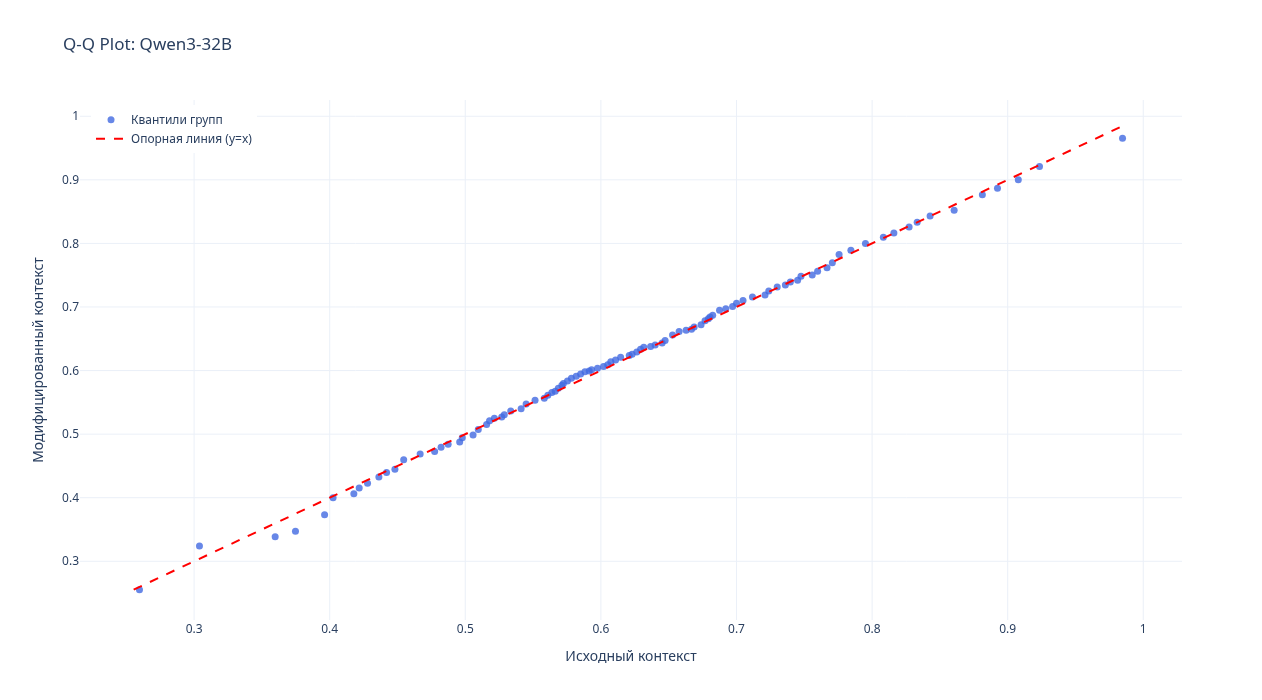

In [8]:
fig = qq_func(list1, list2_1)
# Показываем график
fig.update_layout(
    title='Q-Q Plot: Qwen3-32B',
    xaxis_title='Исходный контекст',
    yaxis_title='Модифицированный контекст',
)
fig.show()

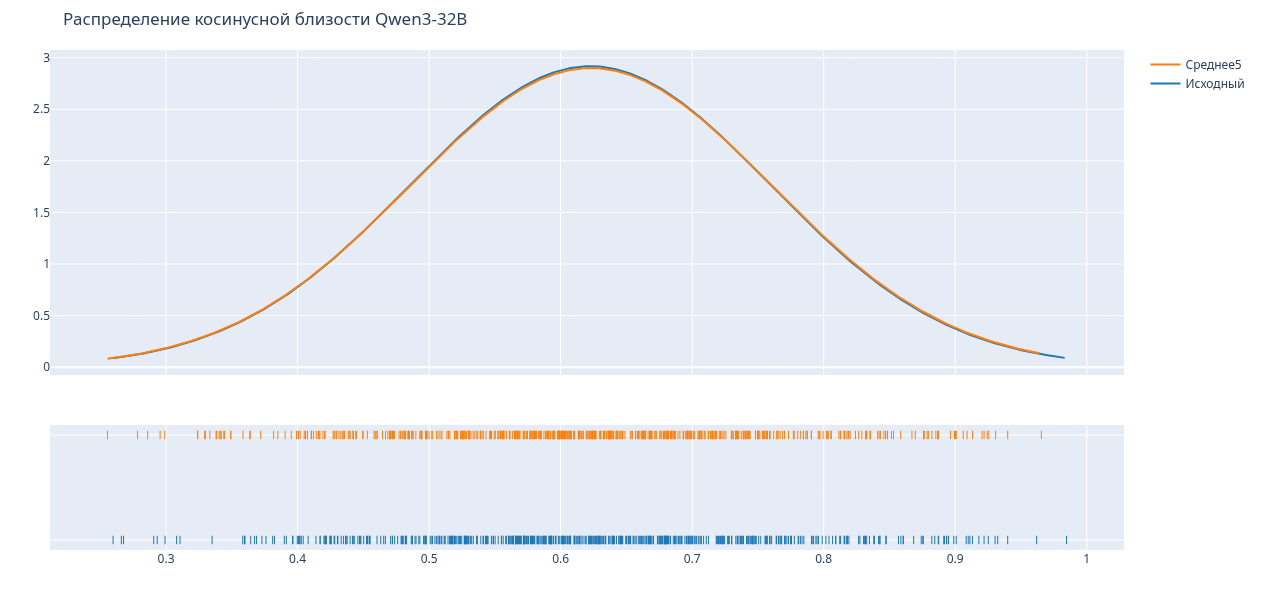

In [9]:
group_labels = ['Исходный', 'Среднее5']

# Create distplot with curve_type set to 'normal'
fig = ff.create_distplot(
    [
        base["similarity"],
        perturb_1["similarity"],
    ], group_labels, 
    bin_size=.01,
    curve_type='normal', # override default 'kde'
    show_hist=False,
    rug_text=[
        base.index,        perturb_1.index,
    ]
)

# Add title
fig.update_layout(title_text='Распределение косинусной близости Qwen3-32B')
# 3. Настраиваем ширину, высоту и другие параметры макета
fig.update_layout(
    width=1200,   # Ширина в пикселях
    height=600,  # Высота в пикселях
    margin=dict(l=50, r=50, t=50, b=50) # Отступы от краев (опционально)
)
fig.show()

In [10]:
group_labels = ['Исходный', 'Среднее5']
group_values = [
    base["similarity"],
    perturb_1["similarity"],
]

In [11]:
# Преобразуем каждый список в pd.Series и объединяем по столбцам (axis=1)
df = pd.concat([pd.Series(v, name=k) for k, v in zip(group_labels, group_values)], axis=1)

# Получаем статистики распределения
stats = df.describe().round(4)

stats

,Исходный,Среднее5
count,549.0000,549.0000
mean,0.6226,0.6230
std,0.1369,0.1377
min,0.2597,0.2554
25%,0.5285,0.5302
50%,0.6178,0.6220
75%,0.7183,0.7159
max,0.9847,0.9655


In [12]:
stats.T

,count,mean,std,min,25%,50%,75%,max
Исходный,549.0,0.6468,0.1358,0.2414,0.5633,0.6500,0.7314,0.9863
Первый5,549.0,0.6407,0.1369,0.2597,0.5535,0.6421,0.7238,0.9844
Среднее5,549.0,0.6434,0.1351,0.2691,0.5565,0.6440,0.7305,0.9847
Первый10,549.0,0.6343,0.1327,0.2081,0.5481,0.6388,0.7198,0.9847
Среднее10,549.0,0.6369,0.1374,0.2320,0.5487,0.6382,0.7260,0.9844


### считаем t-парный

In [15]:
from scipy import stats

In [13]:
def compare_normal_distributions(
    sample_a: np.ndarray, 
    sample_b: np.ndarray, 
    alpha: float = 0.05
) -> tuple[float, float, str]:
    """
    Сравнивает два нормальных распределения, автоматически выбирая 
    между критерием Стьюдента и критерием Уэлча на основе дисперсий.
    """
    # 1. Проверка гомогенности дисперсий (Критерий Левена)
    # Нулевая гипотеза: дисперсии равны
    stat_levene, p_levene = stats.levene(sample_a, sample_b)
    
    # Если p_levene > alpha, мы не можем отвергнуть нулевую гипотезу (дисперсии равны)
    equal_variances = bool(p_levene > alpha)
    
    # 2. Расчет t-критерия
    # Параметр equal_var=False автоматически применяет поправку Уэлча
    t_stat, p_val = stats.ttest_ind(
        sample_a, 
        sample_b, 
        equal_var=equal_variances
    )
    
    test_used = "t-критерий Стьюдента" if equal_variances else "t-критерий Уэлча"
    
    return float(t_stat), float(p_val), test_used

In [48]:
t_statistic, p_value, test_name = compare_normal_distributions(base["similarity"],perturb_3["similarity"])

print(f"Использован: {test_name}")
print(f"t-статистика: {t_statistic:.4f}")
print(f"p-value: {p_value:.4e}")

if p_value < 0.10:
    print("Вывод: Разница между распределениями статистически значима.")
else:
    print("Вывод: Статистически значимой разницы нет.")

Использован: t-критерий Стьюдента
t-статистика: 1.1936
p-value: 2.3288e-01
Вывод: Статистически значимой разницы нет.


In [27]:
(base["similarity"] - perturb_3["similarity"]).sort_values()

check_id
10794   -0.219613
9988    -0.174104
3684    -0.148885
9273    -0.143169
2859    -0.128570
           ...   
9865     0.182811
2851     0.185031
2629     0.188234
10267    0.231917
11698    0.297985
Name: similarity, Length: 549, dtype: float64

In [28]:
base.loc[11698]

similarity                                             0.847604
answer            Старший сын Дэвида и Виктории Бэкхем Бруклин.
passage_id                                                485.0
question      Кто будет заниматься продвижением нового арома...
Name: 11698, dtype: object

In [29]:
perturb_3.loc[11698]

similarity                                             0.549619
answer            Старший сын Дэвида и Виктории Бэкхем Бруклин.
passage_id                                                485.0
question      Кто будет заниматься продвижением нового арома...
passage       (1) Младший сын Дэвида и Виктории Бэкхем Брукл...
ptb_words     [{"word": "Младший", "start": 4, "end": 11, "i...
Name: 11698, dtype: object

In [31]:
def welch_ttest(
    sample_a: list| np.ndarray, 
    sample_b: list| np.ndarray, 
    alpha: float = 0.05
) -> tuple[float, float, bool]:
    """
    Вычисляет t-критерий Уэлча для двух независимых выборок.
    
    Аргументы:
        sample_a: Первая выборка (список или numpy array).
        sample_b: Вторая выборка (список или numpy array).
        alpha: Уровень значимости (по умолчанию 0.05).
        
    Возвращает:
        t_stat: Значение t-статистики.
        p_val: Полученное p-value.
        is_significant: True, если разница статистически значима, иначе False.
    """
    
    # Вызов t-критерия с параметром equal_var=False превращает его в критерий Уэлча
    t_stat, p_val = stats.ttest_ind(sample_a, sample_b, equal_var=False)
    
    # Проверка на статистическую значимость
    is_significant = bool(p_val < alpha)
    
    return float(t_stat), float(p_val), is_significant

In [32]:
# Сравниваем
t_statistic, p_value, significant = welch_ttest(base["similarity"],perturb_3["similarity"], alpha=0.05)

print("--- Результаты t-критерия Уэлча ---")
print(f"t-статистика: {t_statistic:.4f}")
print(f"p-value:      {p_value:.4e}")
print("-" * 35)

if significant:
    print("Вывод: Отвергаем нулевую гипотезу.")
    print("Между выборками есть статистически значимая разница.")
else:
    print("Вывод: Не отвергаем нулевую гипотезу.")
    print("Статистически значимой разницы не обнаружено.")

--- Результаты t-критерия Уэлча ---
t-статистика: 1.1936
p-value:      2.3288e-01
-----------------------------------
Вывод: Не отвергаем нулевую гипотезу.
Статистически значимой разницы не обнаружено.


In [39]:
len(perturb_3["passage"].iloc[0].split(" "))

179

In [45]:
perturb_3["passage"].str.split(" ").transform(len).describe()

count    549.000000
mean     216.639344
std       65.600575
min      160.000000
25%      179.000000
50%      202.000000
75%      222.000000
max      514.000000
Name: passage, dtype: float64